In [3]:
import os
import io
import sys
import cv2
import glob
import torch
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import torchvision.transforms as transforms

In [4]:
PROJECT_PATH = "/Users/saratramontana/Documents/GitHub/test_segmentation_model"
OVAMTA_PATH = "/Users/saratramontana/Documents/GitHub/test_segmentation_model/external/OvaMTA"

sys.path.append(PROJECT_PATH)
sys.path.append(OVAMTA_PATH)

from new_data.data_loader import train_df, val_df

from lib.OvaMTA_seg import TransRaUNet_CLF_xiaorong as OvaSegModel
from lib.OvaMTA_diag import TransRaUNet_CLF_xiaorong as OvaDiagModel

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# print("Device:", device)
# print("Train df:", train_df.shape)
# print("Val df:", val_df.shape)
# print("Train labels:")
# print(train_df["risk_class"].value_counts())
# print("Val labels:")
# print(val_df["risk_class"].value_counts())

/Users/saratramontana/anaconda3/envs/test-seg/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/saratramontana/anaconda3/envs/test-seg/lib/python3.12/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/Users/saratramontana/anaconda3/envs/test-seg/lib/python3.12/site-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/Users/saratramontana/Documents/GitHub/test_segmentation_model/external/OvaMTA/lib/pvtv2.py:387: UserWarni

In [5]:
seg_ckpt_path = "/Users/saratramontana/Documents/GitHub/test_segmentation_model/models/test_ovamta_seg/f9m409xb/checkpoints/epoch=6-step=98.ckpt"
diag_ckpt_path = "/Users/saratramontana/Documents/GitHub/test_segmentation_model/models/test_ovamta_diag/m3ezw513/checkpoints/epoch=0-step=14.ckpt"

In [ ]:
def load_lightning_checkpoint_into_ovamta(model, ckpt_path, device):
    ckpt = torch.load(ckpt_path, map_location=device)
    state_dict = ckpt["state_dict"]

    new_state_dict = {}

    for k, v in state_dict.items():
        if k.startswith("model."):
            new_key = k.replace("model.", "", 1) #perchè Lightning salva i pesi così:"model.encoder.conv1.weight", mentre il modello puro si aspetta: "encoder.conv1.weight" quindi devo rimuovere quel model.

            new_state_dict[new_key] = v

    model.load_state_dict(new_state_dict)
    model.to(device)
    model.eval()

    return model

In [ ]:
model_seg = OvaSegModel(training=False)
model_diag = OvaDiagModel(training=False)

model_seg = load_lightning_checkpoint_into_ovamta(model_seg, seg_ckpt_path, device)
model_diag = load_lightning_checkpoint_into_ovamta(model_diag, diag_ckpt_path, device)

print("Stage 1 OvaMTA-Seg loaded.")
print("Stage 2 OvaMTA-Diag loaded.")

Stage 1 OvaMTA-Seg loaded.
Stage 2 OvaMTA-Diag loaded.


In [8]:
TR_SIZE = 352

img_transform = transforms.Compose([
    transforms.Resize((TR_SIZE, TR_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

In [ ]:
def predict_stage1_roi(image, model_seg, device, margin_352=10, ovary_threshold=0.1):
    orig_w, orig_h = image.size

    x = img_transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        out5, out4, out3, out2, cls_out_seg, features = model_seg(x)
        res = out5 + out4 + out3 + out2

        mask_pred_352 = (res[0, 0] > 0).cpu().numpy().astype(np.uint8)

        stage1_raw = cls_out_seg[0].detach().cpu().numpy()
        p_healthy = float(stage1_raw[0])
        p_benign_mass = float(stage1_raw[1])
        p_malignant_mass = float(stage1_raw[2])

    contours, _ = cv2.findContours(
        mask_pred_352,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_NONE
    )

    if len(contours) == 0:
        bbox = (0, 0, orig_w, orig_h)
        has_roi = False
    else:
        c = max(contours, key=cv2.contourArea)
        x_352, y_352, w_352, h_352 = cv2.boundingRect(c)

        x1_352 = max(0, x_352 - margin_352)
        y1_352 = max(0, y_352 - margin_352)
        x2_352 = min(TR_SIZE, x_352 + w_352 + margin_352)
        y2_352 = min(TR_SIZE, y_352 + h_352 + margin_352)

        scale_x = orig_w / TR_SIZE
        scale_y = orig_h / TR_SIZE

        x_min = int(x1_352 * scale_x)
        y_min = int(y1_352 * scale_y)
        x_max = int(x2_352 * scale_x)
        y_max = int(y2_352 * scale_y)

        x_min = max(0, x_min)
        y_min = max(0, y_min)
        x_max = min(orig_w, x_max)
        y_max = min(orig_h, y_max)

        if x_max <= x_min or y_max <= y_min:
            bbox = (0, 0, orig_w, orig_h)
            has_roi = False
        else:
            bbox = (x_min, y_min, x_max, y_max)
            has_roi = True

    is_ovary = p_healthy >= ovary_threshold

    return {
        "mask_pred_352": mask_pred_352,
        "bbox": bbox,
        "has_roi": has_roi,
        "is_ovary": is_ovary,
        "is_mass": not is_ovary,
        "stage1_raw": stage1_raw,
        "p_healthy": p_healthy,
        "p_benign_mass": p_benign_mass,
        "p_malignant_mass": p_malignant_mass,
    }

In [ ]:
def predict_stage2_diagnosis(image, bbox, model_diag, device, benign_threshold=0.65):
    x_min, y_min, x_max, y_max = bbox

    if x_max <= x_min or y_max <= y_min:
        x_min, y_min, x_max, y_max = 0, 0, image.size[0], image.size[1]

    patch = image.crop((x_min, y_min, x_max, y_max))
    x_patch = img_transform(patch).unsqueeze(0).to(device)

    with torch.no_grad():
        out5, out4, out3, out2, cls_out_diag, features = model_diag(x_patch)

    raw = cls_out_diag[0].detach().cpu().numpy()

    p_benign_raw = float(raw[0])
    p_malignant_raw = float(raw[1])

    if p_benign_raw > benign_threshold:
        pred_label = 0
        pred_class = "benign"
    else:
        pred_label = 1
        pred_class = "malignant"

    probs = torch.softmax(cls_out_diag, dim=1)[0].detach().cpu().numpy()

    return {
        "patch": patch,
        "stage2_raw": raw,
        "stage2_softmax": probs,
        "p_benign_raw": p_benign_raw,
        "p_malignant_raw": p_malignant_raw,
        "prob_benign_softmax": float(probs[0]),
        "prob_malignant_softmax": float(probs[1]),
        "pred_label": pred_label,
        "pred_class": pred_class
    }

In [ ]:
def ovamta_inference_one_row(row, model_seg, model_diag, device):
    image = Image.open(io.BytesIO(row["image"])).convert("RGB")

    stage1 = predict_stage1_roi(
        image=image,
        model_seg=model_seg,
        device=device,
        margin_352=10,
        ovary_threshold=0.1
    )

    true_label = int(row["risk_class"])

    if stage1["is_ovary"]:
        return {
            "image": image,
            "mask_pred_352": stage1["mask_pred_352"],
            "bbox": stage1["bbox"],
            "has_roi": stage1["has_roi"],
            "stage1_raw": stage1["stage1_raw"],
            "p_healthy": stage1["p_healthy"],
            "p_benign_mass": stage1["p_benign_mass"],
            "p_malignant_mass": stage1["p_malignant_mass"],

            "patch": None,
            "stage2_raw": None,
            "stage2_softmax": None,
            "p_benign_raw": None,
            "p_malignant_raw": None,
            "prob_benign_softmax": None,
            "prob_malignant_softmax": None,

            "pred_label": 2,
            "pred_class": "healthy_ovary",

            "true_label": true_label,
            "true_class": (
                "healthy_ovary" if true_label == 2
                else "malignant" if true_label == 1
                else "benign"
            )
        }

    stage2 = predict_stage2_diagnosis(
        image=image,
        bbox=stage1["bbox"],
        model_diag=model_diag,
        device=device,
        benign_threshold=0.65
    )

    return {
        "image": image,
        "mask_pred_352": stage1["mask_pred_352"],
        "bbox": stage1["bbox"],
        "has_roi": stage1["has_roi"],
        "stage1_raw": stage1["stage1_raw"],
        "p_healthy": stage1["p_healthy"],
        "p_benign_mass": stage1["p_benign_mass"],
        "p_malignant_mass": stage1["p_malignant_mass"],

        "patch": stage2["patch"],
        "stage2_raw": stage2["stage2_raw"],
        "stage2_softmax": stage2["stage2_softmax"],
        "p_benign_raw": stage2["p_benign_raw"],
        "p_malignant_raw": stage2["p_malignant_raw"],
        "prob_benign_softmax": stage2["prob_benign_softmax"],
        "prob_malignant_softmax": stage2["prob_malignant_softmax"],
        "pred_label": stage2["pred_label"],
        "pred_class": stage2["pred_class"],

        "true_label": true_label,
        "true_class": (
            "healthy_ovary" if true_label == 2
            else "malignant" if true_label == 1
            else "benign"
        )
    }

In [12]:
idx = 0
row = val_df.iloc[idx]

result = ovamta_inference_one_row(
    row=row,
    model_seg=model_seg,
    model_diag=model_diag,
    device=device
)

print("True:", result["true_label"], result["true_class"])
print("Pred:", result["pred_label"], result["pred_class"])
print("BBox:", result["bbox"])
print("Has ROI:", result["has_roi"])
print("Stage 1 raw [ovary, benign, malignant]:", result["stage1_raw"])
print("Stage 2 raw [benign, malignant]:", result["stage2_raw"])
print("Stage 2 softmax:", result["stage2_softmax"])

True: 1 malignant
Pred: 1 malignant
BBox: (26, 67, 218, 187)
Has ROI: True
Stage 1 raw [ovary, benign, malignant]: [0.03681542 0.50532484 0.56015724]
Stage 2 raw [benign, malignant]: [0.3039855 0.7411518]
Stage 2 softmax: [0.39241636 0.6075836 ]


In [13]:
print(result["stage2_raw"])

[0.3039855 0.7411518]


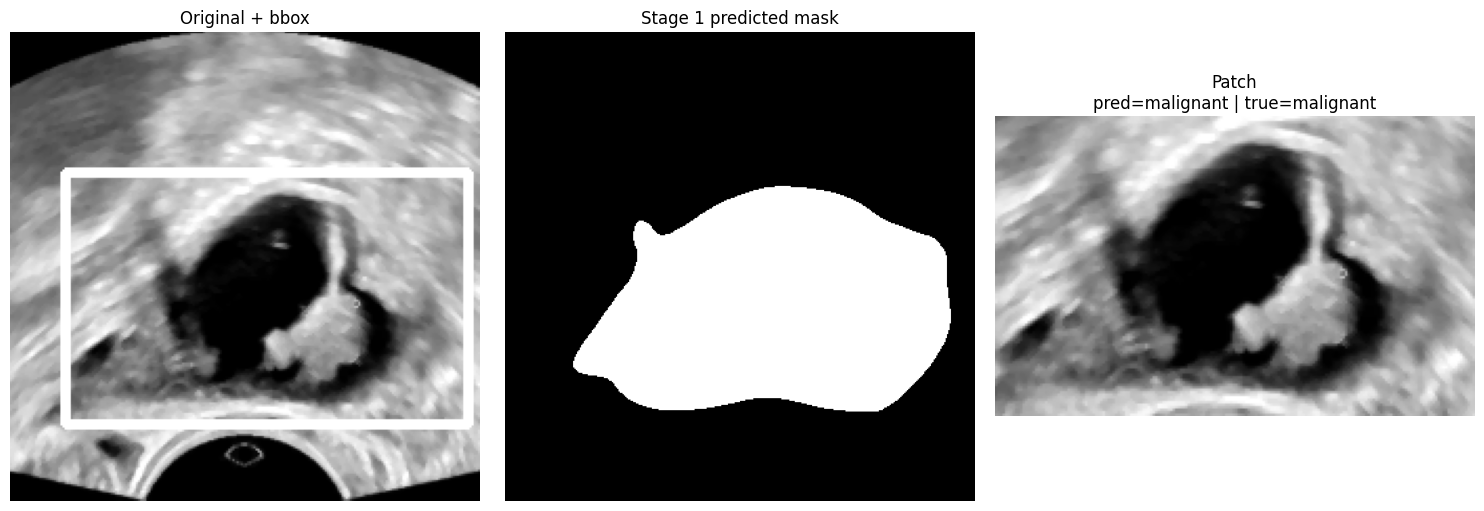

In [14]:
def show_inference_result(result):
    image_np = np.array(result["image"])
    x_min, y_min, x_max, y_max = result["bbox"]

    image_box = image_np.copy()

    cv2.rectangle(
        image_box,
        (x_min, y_min),
        (x_max, y_max),
        color=(255, 255, 255),
        thickness=3
    )

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(image_box)
    plt.title("Original + bbox")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(result["mask_pred_352"], cmap="gray")
    plt.title("Stage 1 predicted mask")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(result["patch"])
    plt.title(
        f"Patch\npred={result['pred_class']} | true={result['true_class']}"
    )
    plt.axis("off")

    plt.tight_layout()
    plt.show()

show_inference_result(result)

In [15]:
all_results = []

for idx in range(len(val_df)):
    row = val_df.iloc[idx]

    result = ovamta_inference_one_row(
        row=row,
        model_seg=model_seg,
        model_diag=model_diag,
        device=device
    )

    all_results.append({
        "idx": idx,
        "true_label": result["true_label"],
        "true_class": result["true_class"],
        "pred_label": result["pred_label"],
        "pred_class": result["pred_class"],
        "has_roi": result["has_roi"],
        "bbox": result["bbox"],
        "p_benign_raw": result["p_benign_raw"],
        "p_malignant_raw": result["p_malignant_raw"],
        "prob_benign_softmax": result["prob_benign_softmax"],
        "prob_malignant_softmax": result["prob_malignant_softmax"],
        "stage1_raw": result["stage1_raw"],
        "stage2_raw": result["stage2_raw"],
    })

results_df = pd.DataFrame(all_results)
results_df.head()

,idx,true_label,true_class,pred_label,pred_class,has_roi,bbox,p_benign_raw,p_malignant_raw,prob_benign_softmax,prob_malignant_softmax,stage1_raw,stage2_raw
0,0,1,malignant,1,malignant,True,"(26, 67, 218, 187)",0.303986,0.741152,0.392416,0.607584,"[0.03681542, 0.50532484, 0.56015724]","[0.3039855, 0.7411518]"
1,1,1,malignant,1,malignant,True,"(23, 82, 197, 191)",0.303644,0.741040,0.392362,0.607638,"[0.005667121, 0.15717335, 0.8224934]","[0.3036436, 0.7410396]"
2,2,1,malignant,1,malignant,True,"(23, 29, 199, 203)",0.304492,0.739221,0.392998,0.607002,"[0.010214708, 0.22033286, 0.76405317]","[0.3044918, 0.73922116]"
3,3,1,malignant,1,malignant,True,"(33, 26, 215, 207)",0.304919,0.738784,0.393204,0.606796,"[0.014316957, 0.2636359, 0.7267879]","[0.30491924, 0.73878396]"
4,4,1,malignant,1,malignant,True,"(57, 65, 224, 206)",0.303981,0.738503,0.393047,0.606953,"[0.010436922, 0.17977218, 0.7803904]","[0.30398068, 0.7385032]"


In [16]:
accuracy = (results_df["true_label"] == results_df["pred_label"]).mean()
print("Validation accuracy:", accuracy)

pd.crosstab(
    results_df["true_class"],
    results_df["pred_class"],
    rownames=["True"],
    colnames=["Pred"]
)

Validation accuracy: 0.9117647058823529


Pred,malignant
True,
benign,6
malignant,62


In [17]:
results_df.to_csv("ovamta_inference_results_val.csv", index=False)
print("Saved: ovamta_inference_results_val.csv")

Saved: ovamta_inference_results_val.csv
